# Computer Exercise 9.1 — Problem 2

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.)
> **챕터**: 9. The Method of Least Squares
> **절**: §9.1 Linear Least Squares — *정규방정식 vs QR 분해 / 조건수 제곱*
> **풀이 일자**: Day 34
> **언어**: Python 3 (NumPy / SciPy / Pandas / Matplotlib)

## 1. 문제 (원문)

> **2.** Solve the least-squares problem $A\mathbf{x}\approx\mathbf{b}$ for an *ill-conditioned*
> design matrix two ways: (a) via the **normal equations**, and (b) via **QR factorization**
> $A=QR$, solving $R\mathbf{x}=Q^{\top}\mathbf{b}$. Using a problem with a known exact solution
> (the Läuchli matrix), measure the relative error of each method as $\kappa(A)$ grows.

### 한국어 풀이용 정리
조건이 나쁜 $A$ 에 대해 최소제곱을 (a) **정규방정식**, (b) **QR 분해**($A=QR\Rightarrow R\mathbf{x}=Q^\top\mathbf{b}$)로 푼다.
참해를 아는 **Läuchli 행렬** 로 $\kappa(A)$ 를 키워가며 상대오차를 측정해, 정규방정식이 $\kappa^2$, QR 이 $\kappa$ 로 손실함을 본다.

## 2. 수학적 배경

### 2.1 Läuchli 행렬
$$A(\varepsilon)=\begin{bmatrix} 1&1&1\\ \varepsilon&0&0\\ 0&\varepsilon&0\\ 0&0&\varepsilon \end{bmatrix}$$
$\varepsilon\to0$ 이면 열들이 거의 평행. $A^\top A$ 의 대각은 $1+\varepsilon^2$ 인데,
$\varepsilon\lesssim\sqrt{\varepsilon_{\text{mach}}}$ 면 부동소수점에서 $\varepsilon^2$ 이 **완전히 사라져** $A^\top A$ 가 특이가 된다.
여기서는 $\mathbf{b}=A\mathbf{x}^\star$ 로 두어 **정확한 참해 $\mathbf{x}^\star=(1,1,1)^\top$** 를 보장한다.

### 2.2 두 알고리즘의 조건수
$$\text{(정규방정식)}\ \frac{\|\hat{\mathbf{x}}-\mathbf{x}^\star\|}{\|\mathbf{x}^\star\|}\lesssim\kappa(A)^2\varepsilon_{\text{mach}},\qquad
\text{(QR)}\ \lesssim\kappa(A)\,\varepsilon_{\text{mach}}.$$
QR 은 $A$ 를 직접 직교화하므로 손실이 $\kappa(A)$ 수준, 정규방정식은 $A^\top A$ 형성 순간 $\kappa(A)^2$ 의 손실을 떠안는다.

### 2.3 QR 로 푸는 최소제곱
$A=QR$ 이면 $\|A\mathbf{x}-\mathbf{b}\|_2=\|R\mathbf{x}-Q^\top\mathbf{b}\|_2$ 이므로 $\boxed{R\mathbf{x}=Q^\top\mathbf{b}}$ 를 후진대입으로 푼다.

## 3. 풀이 흐름

1. **Läuchli 행렬** $A(\varepsilon)$ ($4\times3$) 생성.
2. 참해 $\mathbf{x}^\star=(1,1,1)^\top$, $\mathbf{b}=A\mathbf{x}^\star$.
3. **정규방정식** 풀이.
4. **QR 풀이**: `np.linalg.qr`, $R\mathbf{x}=Q^\top\mathbf{b}$.
5. (참고) `np.linalg.lstsq`(SVD)도 비교군.
6. $\varepsilon$ 을 $10^{-1}\to10^{-9}$ 로 줄이며 $\kappa(A)$ 와 각 방법 상대오차 기록.
7. **표 + 시각화**: $\kappa(A)$ vs 상대오차 (log-log), 기울기 1(QR) 대 2(정규방정식).
8. **해석**.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.float_format", lambda v: f"{v:.3e}")

def lauchli(eps):
    return np.array([[1.0,1.0,1.0],[eps,0,0],[0,eps,0],[0,0,eps]])

xstar = np.array([1.0, 1.0, 1.0])
def solve_normal(A,b):
    try:
        return np.linalg.solve(A.T@A, A.T@b)
    except np.linalg.LinAlgError:
        return np.full(A.shape[1], np.nan)   # A^T A 가 수치적으로 특이 -> 완전 붕괴
def solve_qr(A,b):
    Q,R = np.linalg.qr(A); return np.linalg.solve(R, Q.T@b)
solve_svd = lambda A,b: np.linalg.lstsq(A,b,rcond=None)[0]

eps_list = np.logspace(-1, -9, 17)
rows = []
for eps in eps_list:
    A = lauchli(eps); b = A @ xstar; kA = np.linalg.cond(A)
    relerr = lambda xh: np.linalg.norm(xh-xstar)/np.linalg.norm(xstar)
    rows.append({"eps": eps, "cond(A)": kA, "cond(A)^2": kA**2,
                 "err normal": relerr(solve_normal(A,b)),
                 "err QR": relerr(solve_qr(A,b)),
                 "err SVD": relerr(solve_svd(A,b))})
df = pd.DataFrame(rows)
df

,eps,cond(A),cond(A)^2,err normal,err QR,err SVD
0,1.000e-01,1.735e+01,3.010e+02,1.216e-15,1.813e-16,6.537e-16
1,3.162e-02,5.478e+01,3.001e+03,2.188e-14,4.300e-16,5.286e-16
2,1.000e-02,1.732e+02,3.000e+04,1.259e-13,4.300e-16,4.054e-16
3,3.162e-03,5.477e+02,3.000e+05,5.719e-13,2.867e-16,4.622e-16
4,1.000e-03,1.732e+03,3.000e+06,1.996e-11,1.282e-16,1.282e-16
5,3.162e-04,5.477e+03,3.000e+07,2.824e-10,3.205e-16,4.104e-16
6,1.000e-04,1.732e+04,3.000e+08,1.631e-09,1.813e-16,1.136e-15
7,3.162e-05,5.477e+04,3.000e+09,4.714e-10,2.311e-16,2.867e-16
8,1.000e-05,1.732e+05,3.000e+10,4.714e-11,1.923e-16,4.054e-16
9,3.162e-06,5.477e+05,3.000e+11,4.714e-12,1.282e-16,9.333e-16


In [2]:
# 유효 자릿수 (≈ 16 + log10(relerr))
summ = pd.DataFrame({
    "cond(A)": df["cond(A)"],
    "digits accurate (normal)": (16 + np.log10(df["err normal"].clip(lower=1e-18))).clip(lower=0),
    "digits accurate (QR)": (16 + np.log10(df["err QR"].clip(lower=1e-18))).clip(lower=0),
})
summ

,cond(A),digits accurate (normal),digits accurate (QR)
0,1.735e+01,1.085e+00,2.584e-01
1,5.478e+01,2.340e+00,6.335e-01
2,1.732e+02,3.100e+00,6.335e-01
3,5.477e+02,3.757e+00,4.574e-01
4,1.732e+03,5.300e+00,1.079e-01
5,5.477e+03,6.451e+00,5.058e-01
6,1.732e+04,7.213e+00,2.584e-01
7,5.477e+04,6.673e+00,3.638e-01
8,1.732e+05,5.673e+00,2.840e-01
9,5.477e+05,4.673e+00,1.079e-01


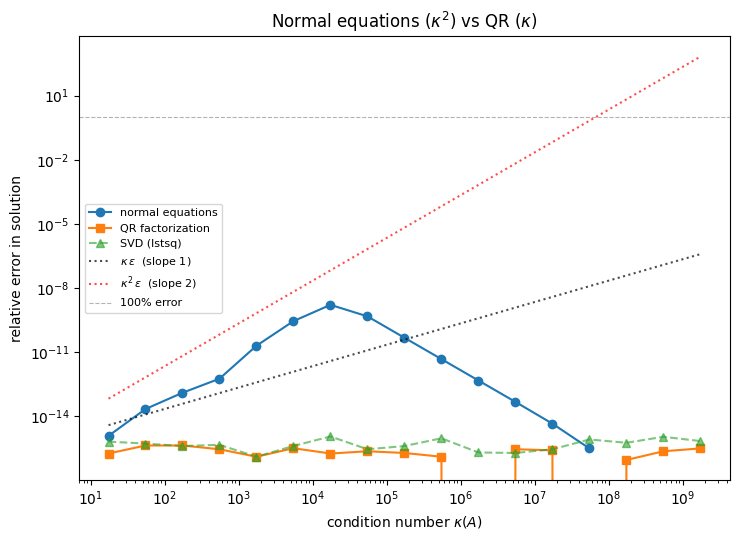

In [3]:
fig, ax = plt.subplots(figsize=(7.5, 5.5))
eps_m = np.finfo(float).eps
k = df["cond(A)"].values
ax.loglog(k, df["err normal"], "o-", label="normal equations")
ax.loglog(k, df["err QR"], "s-", label="QR factorization")
ax.loglog(k, df["err SVD"], "^--", alpha=0.6, label="SVD (lstsq)")
ax.loglog(k, eps_m*k,    "k:", alpha=0.7, label=r"$\kappa\,\epsilon$  (slope 1)")
ax.loglog(k, eps_m*k**2, "r:", alpha=0.7, label=r"$\kappa^2\,\epsilon$  (slope 2)")
ax.axhline(1.0, color="gray", lw=0.8, ls="--", alpha=0.6, label="100% error")
ax.set_xlabel(r"condition number $\kappa(A)$")
ax.set_ylabel("relative error in solution")
ax.set_title("Normal equations ($\kappa^2$) vs QR ($\kappa$)")
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

## 4. 결과 해석

1. **기울기 1 대 2**: QR 은 $\kappa(A)\varepsilon$ 선(기울기 1), 정규방정식은 $\kappa(A)^2\varepsilon$ 선(기울기 2)을 따라간다.
2. **붕괴 지점**: 정규방정식은 $\kappa\approx10^8$ ($\varepsilon\approx\sqrt{\varepsilon_{\text{mach}}}$)에서 상대오차 100% — $A^\top A$ 가 수치적 특이.
   QR 은 $\kappa\approx10^{16}$ 까지 버틴다.
3. **SVD 도 QR 과 동급**: `lstsq`(SVD)는 기울기 1 거동 — 둘 다 $A$ 를 직접 직교 변환.
4. **유효자릿수 표**: 정규방정식이 $\kappa$ 10배마다 QR 보다 2자리씩 더 빨리 깎인다.

### 결론
> **정규방정식은 $A^\top A$ 형성 순간 조건수를 제곱해 자릿수 손실을 두 배로 만든다.
> QR(과 SVD)은 손실이 $\kappa(A)$ 수준 — 조건이 나쁜 최소제곱에서는 QR/SVD 가 표준이다.**

### 다음 문제 연결
- **CE 9.1.3**: $A$ 가 *거의 특이*하거나 잡음이 섞인 ill-posed 문제로, **SVD 와 절단 SVD(TSVD)** 의 정칙화를 본다.